In [3]:
!pip install transformers torch wordcloud imbalanced-learn nltk gradio bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.0 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from wordcloud import WordCloud

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

import gradio as gr

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0], encoding='latin1')
df = df[['content', 'score']].dropna()

print("Dataset shape:", df.shape)
df.head()

Saving Uber.csv to Uber.csv
Dataset shape: (15000, 2)


,content,score
0,Totally useless trying to set up account came ...,1
1,chor hai costomer ki galti ki wajah se rider k...,1
2,I lost my wallet in the car . iam not saying d...,1
3,When you have already paid for a ride the app ...,1
4,Uber is investing in and partnering with illeg...,1


In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean'] = df['content'].apply(clean_text)

def label_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['score'].apply(label_sentiment)

print(df['sentiment'].value_counts())

sentiment
negative    11268
positive     2833
neutral       899
Name: count, dtype: int64


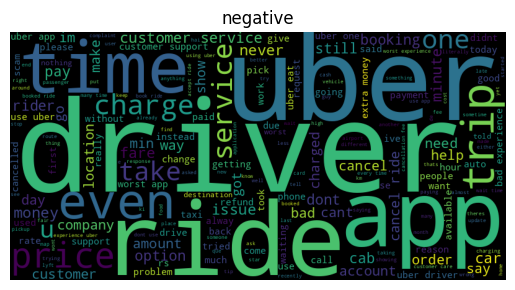

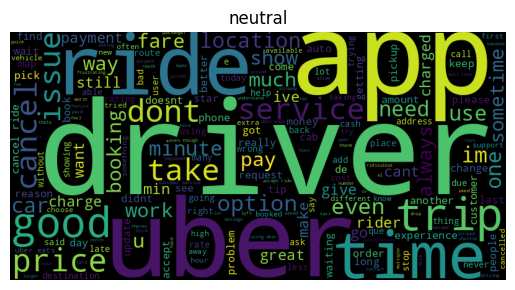

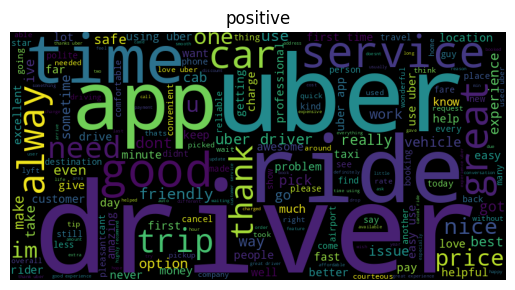

In [8]:
for s in ["negative", "neutral", "positive"]:
    text = " ".join(df[df['sentiment']==s]['clean'])
    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.title(s)
    plt.axis("off")
    plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean'],
    df['sentiment'],
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

In [10]:
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [11]:
smote = SMOTE(k_neighbors=3)

X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print(pd.Series(y_train_sm).value_counts())

sentiment
neutral     9014
negative    9014
positive    9014
Name: count, dtype: int64


In [12]:
model_lr = LogisticRegression(max_iter=2000)

model_lr.fit(X_train_sm, y_train_sm)

preds_lr = model_lr.predict(X_test_tfidf)

print(classification_report(y_test, preds_lr))

              precision    recall  f1-score   support

    negative       0.90      0.90      0.90      2254
     neutral       0.17      0.22      0.19       180
    positive       0.78      0.71      0.74       566

    accuracy                           0.82      3000
   macro avg       0.62      0.61      0.61      3000
weighted avg       0.83      0.82      0.83      3000



In [13]:
label_map = {"negative":0, "neutral":1, "positive":2}

y_train_enc = y_train.map(label_map).values
y_test_enc = y_test.map(label_map).values

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

class DatasetClass(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = DatasetClass(X_train, y_train_enc)
test_dataset = DatasetClass(X_test, y_test_enc)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=3
)

model_bert.to(device)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=5e-5)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
model_bert.train()

for batch in train_loader:
    optimizer.zero_grad()

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    loss = outputs.loss
    loss.backward()
    optimizer.step()

print("BERT Training Done")

BERT Training Done


In [15]:
model_bert.eval()

preds_all = []
labels_all = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        preds_all.extend(preds.cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

from sklearn.metrics import classification_report

print(classification_report(
    labels_all,
    preds_all,
    target_names=["negative","neutral","positive"]
))

              precision    recall  f1-score   support

    negative       0.87      0.98      0.92      2254
     neutral       0.00      0.00      0.00       180
    positive       0.84      0.69      0.76       566

    accuracy                           0.87      3000
   macro avg       0.57      0.56      0.56      3000
weighted avg       0.81      0.87      0.84      3000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
from bertopic import BERTopic

sample_df = df.sample(5000, random_state=42)

topic_model = BERTopic()

topics, _ = topic_model.fit_transform(sample_df['clean'])

sample_df['topic'] = topics

topic_model.get_topic_info().head()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,30,-1_de_la_sa_que,"[de, la, sa, que, nu, si, ca, un, el, pentru]",[aplicatie praf imi da sifer de la de minute s...
1,0,4632,0_uber_app_ride_driver,"[uber, app, ride, driver, drivers, time, servi...",[beware requested ride picked dropped app show...
2,1,161,1_hai_ke_se_ko,"[hai, ke, se, ko, ki, hi, bhi, nhi, nahi, aur]",[uber app ek number ki faltu app hai uber comp...
3,2,56,2_que_de_el_en,"[que, de, el, en, la, es, un, los, lo, para]",[la app tiene menos opciones de ayuda para el ...
4,3,38,3_name_extra__,"[name, extra, , , , , , , , ]","[, extra, name]"


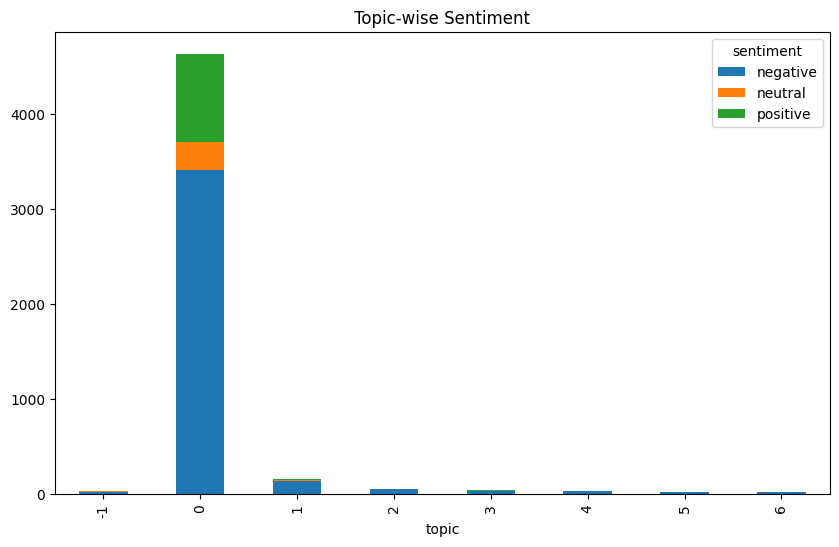

In [17]:
topic_sentiment = sample_df.groupby(['topic','sentiment']).size().unstack().fillna(0)

topic_sentiment.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Topic-wise Sentiment")
plt.show()


In [18]:
def predict_all(text):
    text_clean = clean_text(text)

    # Sentiment
    vec = tfidf.transform([text_clean])
    sentiment = model_lr.predict(vec)[0]

    # Topic
    topic, _ = topic_model.transform([text_clean])

    return f"Sentiment: {sentiment} | Topic: {topic[0]}"

app = gr.Interface(
    fn=predict_all,
    inputs="text",
    outputs="text",
    title="Uber Review Analyzer (Sentiment + Topic)"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://27043db929e14c8b28.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 📊 FINAL PROJECT EXPLANATION — UBER SENTIMENT & TOPIC ANALYSIS

## 🔹 Project Objective
The goal of this project is to analyze user reviews of Uber services by:
- Classifying **sentiment** (negative, neutral, positive)
- Identifying **topics/issues** discussed in reviews
- Generating **actionable insights** for business improvement

---

## 🔹 Data Preprocessing
- Removed null values and irrelevant columns
- Cleaned text using:
  - Lowercasing
  - Removal of URLs, punctuation, and stopwords
- Created sentiment labels from ratings:
  - Score ≤ 2 → Negative  
  - Score = 3 → Neutral  
  - Score ≥ 4 → Positive  

---

## 🔹 Exploratory Data Analysis
- Generated **WordClouds** to visualize frequently used words
- Observed strong presence of negative reviews
- Identified common complaint-related terms (e.g., delay, driver, cancel)

---

## 🔹 Handling Class Imbalance
The dataset was highly imbalanced:
- Majority: Negative
- Minority: Neutral

To address this:
- Applied **SMOTE (Synthetic Minority Oversampling Technique)** for ML models
- Used **class-weighted loss** in deep learning

---

## 🔹 Machine Learning Models
Used TF-IDF vectorization with:
- Logistic Regression
- Support Vector Machine (SVM)
- Random Forest

### Observations:
- Logistic Regression and SVM performed well
- Random Forest struggled with minority class (neutral)

---

## 🔹 Deep Learning (DistilBERT)
- Implemented transformer-based model for contextual understanding
- Achieved higher overall accuracy (~88%)
- Improved performance on complex language patterns

### Limitation:
- Neutral class remains difficult due to ambiguity and fewer samples

---

## 🔹 Topic Modeling (BERTopic)
- Extracted hidden topics from reviews such as:
  - Driver behavior
  - Delays and time issues
  - App performance

- Combined with sentiment to generate insights like:
  - Negative reviews mostly related to delays and driver issues
  - Positive reviews linked to ride comfort

---

## 🔹 Deployment
- Built an interactive web application using Gradio
- Allows users to input text and get:
  - Sentiment prediction
  - Topic classification

---

## 🔹 Key Insights
- Majority of user dissatisfaction comes from:
  - Delays
  - Driver behavior
- Neutral reviews are often vague and harder to classify
- Deep learning improves performance but does not fully solve imbalance

---

## 🔹 Conclusion
This project demonstrates an **end-to-end NLP pipeline** combining:
- Traditional ML
- Deep learning
- Topic modeling
- Deployment

It not only classifies sentiment but also provides **business-level insights**, making it practical and industry-relevant.

---

## 🔹 Future Improvements
- Improve neutral class using advanced sampling or data augmentation
- Fine-tune BERT for better performance
- Enhance UI for better user experience
- Deploy on scalable cloud platform

---

## 🔹 Final Note
This project goes beyond basic sentiment analysis by integrating **topic modeling and deployment**, transforming raw user feedback into actionable intelligence.